In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.layers import LSTM, Dense, Input, Layer
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Attention, GlobalAveragePooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [24]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head(20)

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0000,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0000,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0000,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0000,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0000,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 05:00:00,0.0000,"Kozani, Greece",3.0,3.0,2.0,93.11,0.0,NaN,0.0,19.6,3.6,296.0,1021.0,39.6,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 06:00:00,0.0000,"Kozani, Greece",4.0,1.2,2.0,86.80,0.0,NaN,0.0,20.9,11.2,360.0,1021.0,44.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 07:00:00,0.0000,"Kozani, Greece",6.0,3.6,2.0,75.51,0.0,0.0,0.0,22.3,11.2,340.0,1021.0,63.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 08:00:00,0.0305,"Kozani, Greece",5.0,1.8,2.0,80.95,0.0,0.0,0.0,22.3,14.7,340.0,1021.0,49.9,10.0,6.0,0.0,0.0,Partially cloudy,partly-cloudy-day


In [23]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [25]:
data['solarradiation'].fillna(mean_13_00, inplace=True)


In [27]:
solar_rad = data["solarradiation"]
solar_rad 

datetime
2022-01-01 00:00:00      0.0
2022-01-01 01:00:00      0.0
2022-01-01 02:00:00      0.0
2022-01-01 03:00:00      0.0
2022-01-01 04:00:00      0.0
                       ...  
2024-07-04 19:00:00    207.0
2024-07-04 20:00:00    103.0
2024-07-04 21:00:00      9.0
2024-07-04 22:00:00      0.0
2024-07-04 23:00:00      0.0
Name: solarradiation, Length: 21983, dtype: float64

In [29]:
def df_to_x_y(df, size = 24):
    df_as_numpy = df.to_numpy()
    x = []
    y = []
    for i in range(len(df_as_numpy) - size):
        row = [[a] for a in df_as_numpy[i : i + size]]
        x.append(row)
        label = df_as_numpy[i + size]
        y.append(label)
    
    return np.array(x), np.array(y)

In [30]:
x, y = df_to_x_y(solar_rad, size= 24)

x.shape, y.shape

((21959, 24, 1), (21959,))

In [31]:
x_train = x[: int(0.8*len(x))]
y_train = y[: int(0.8*len(y))]

x_val = x[int(0.8*len(x)): int(0.9*len(x))]
y_val = y[int(0.8*len(y)): int(0.9*len(y))]

x_test = x[int(0.9*len(x)) :]
y_test = y[int(0.9*len(y)):]

x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((17567, 24, 1), (17567,), (2196, 24, 1), (2196,), (2196, 24, 1), (2196,))

In [32]:
checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [33]:
input_shape = (24, 1)

inputs = Input(shape=input_shape)

lstm_out = LSTM(64, return_sequences=True)(inputs)
norm_out = BatchNormalization()(lstm_out)

query = norm_out
value = norm_out

attention_out = Attention()([query, value])
dropout_out = Dropout(0.2)(attention_out)
flattened = Dense(16, activation="relu")(dropout_out)
flattened = BatchNormalization()(flattened)
flattened = GlobalAveragePooling1D()(flattened)
outputs = Dense(1, activation="relu")(flattened)

model_1 = Model(inputs=inputs, outputs=outputs)

model_1.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=1e-3),
    metrics=[RootMeanSquaredError()]
)

model_1.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     16,896 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ lstm_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 24, 16)    │      1,040 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 16)    │         64 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 18,273 (71.38 KB)

 Trainable params: 18,113 (70.75 KB)

 Non-trainable params: 160 (640.00 B)

In [34]:
model_1.fit(x_train, y_train, 
            validation_data = (x_val, y_val), 
            epochs = 40,
            batch_size= 32,
            callbacks=[checkpoint_callback]
            )

Epoch 1/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 96342.2188 - root_mean_squared_error: 310.3099
Epoch 1: val_loss improved from inf to 45305.69531, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 96327.3203 - root_mean_squared_error: 310.2859 - val_loss: 45305.6953 - val_root_mean_squared_error: 212.6534
Epoch 2/40
549/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 76422.2422 - root_mean_squared_error: 276.3849
Epoch 2: val_loss improved from 45305.69531 to 32228.56250, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
549/549 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 76414.6719 - root_mean_squared_error: 276.3711 - val_loss: 32228.5625 - val_root_mean_squared_error: 179.3500
Epoch 3/40
548/549 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 53909.5234 - root_mean_squared_error: 232.0067
Epoch 3: val_loss improved from 32228.56250 to 19305.25000, saving model to D

In [35]:
test_predictions = model_1.predict(x_test).flatten()
test_results = pd.DataFrame({"Val Predictions" : test_predictions, "Real Data" : y_test})
test_results
test_results.index = solar_rad.iloc[-2196:].index

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


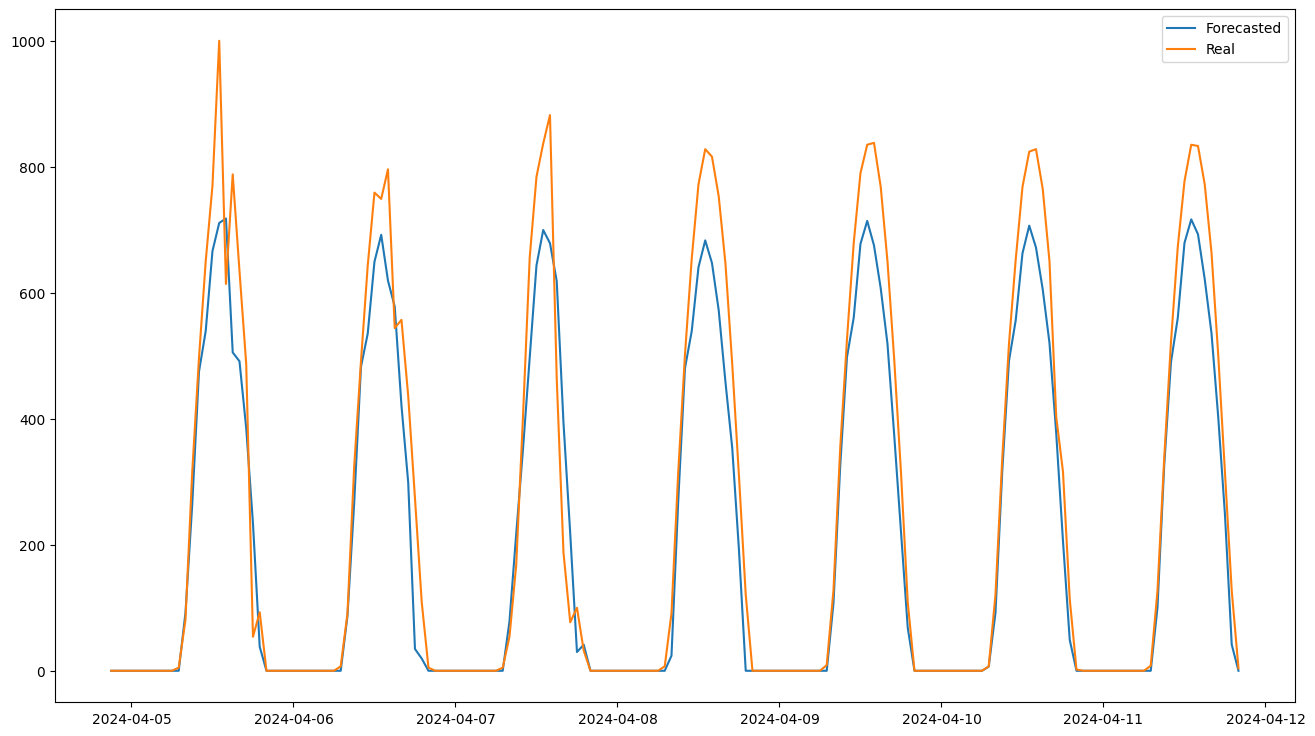

In [11]:
plt.figure(figsize= (16, 9))
plt.plot(test_results["Val Predictions"][9:177], label = "Forecasted")
plt.plot(test_results["Real Data"][9:177], label = "Real")
plt.legend()
plt.show()

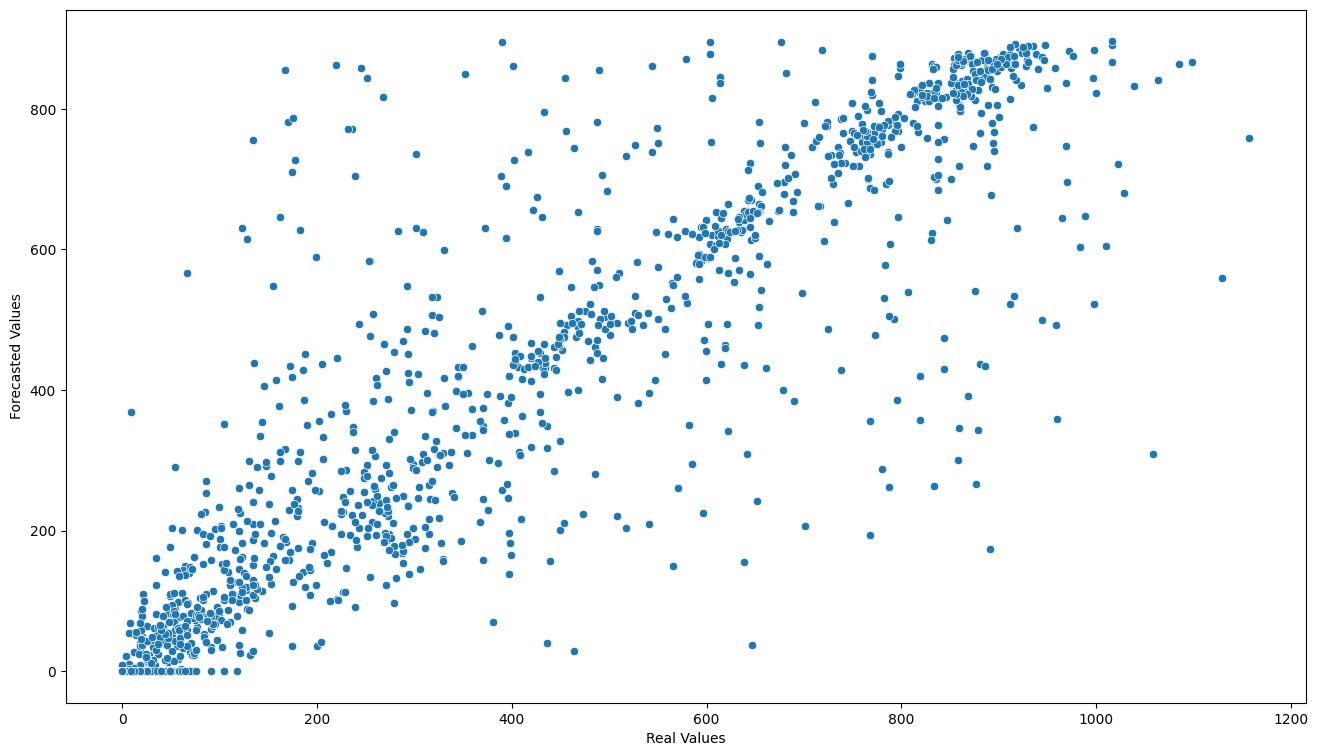

In [36]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = "Real Data", y = "Val Predictions", data = test_results)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.show()

In [37]:
mse = mean_squared_error(test_results["Real Data"], test_results["Val Predictions"])
print(f" Mean Squared Error = {round(mse, 5)} \n Root Mean Squared Error = {round(np.sqrt(mse), 5)}")

ss_total = np.sum((test_results["Real Data"] - test_results["Real Data"].mean()) ** 2)
residual = np.sum((test_results["Real Data"] - test_results["Val Predictions"]) ** 2)
r_squared = 1 - (residual / ss_total)

r_squared

 Mean Squared Error = 12685.98176 
 Root Mean Squared Error = 112.63206


0.8733090004183807